In [1]:
%env CUDA_VISIBLE_DEVICES = 7

env: CUDA_VISIBLE_DEVICES=7


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import cv2
import os
from PIL import Image
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

import torch
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm, tqdm_notebook
import pickle

import sys
sys.path.append("../../batchflow")
sys.path.append('..')

from utils.visualizing import imshow, plot_predicted_mask, plot_origin_data, plot_during_epoch
from utils.train_loop import train, mIoU
from unet.unet_model import Unet
from utils.fetch_dataset_and_processing import AdeDataset, basic_transforms, augmentations_transforms

import albumentations as A
from albumentations.pytorch import ToTensorV2

from batchflow.models.torch.unet import UNet
from batchflow import Pipeline

In [3]:
device = 'cuda:0'

### Load dataset 

In [4]:
size = 256
transforms = augmentations_transforms(size=size)

In [9]:
train_set = AdeDataset(mode='training', root='../unet/ADEChallengeData2016', transforms=transforms)
val_set = AdeDataset(mode='validation', root='../unet/ADEChallengeData2016')
len(train_set), len(val_set)

(20210, 2000)

In [10]:
batch_size = 8
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True) # add GPU 
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=True)

### Train model

In [11]:
IMAGE_SHAPE = (256, 256)
config = {'inputs_shapes': (3, *IMAGE_SHAPE),
          'head': {
                'layout': 'c',
                'channels': 151,
                'kernel_size': 1,
                'stride': 1,
                'padding': 0 
            },
          'device': 'gpu:0'}

In [12]:
unet = UNet(config=config).model

In [11]:
epochs = 30
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(unet.parameters(), lr=1e-4)
#lr_scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=7, gamma=0.1)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, min_lr=1e-8)
path = 'batchflow/b_unet_1.0.pth'
name = 'batchflow/b_unet_1.0'

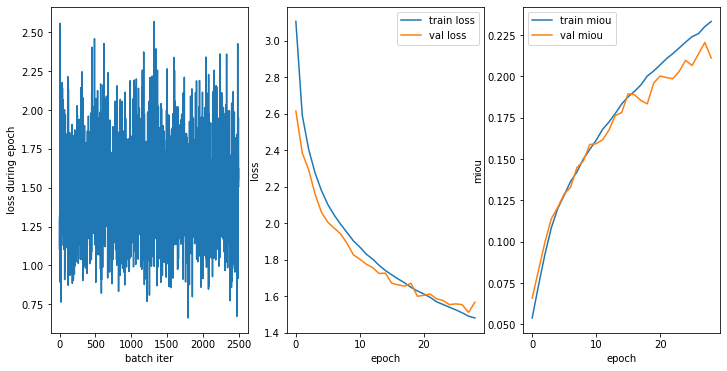

train iter:: 2527it [11:39,  3.61it/s]
val iter:: 250it [00:33,  7.47it/s]


In [12]:
losses, metrics = train(model=unet, opt=optimizer, metrics_function=mIoU,
                        loss_fn=loss_fn, lr_scheduler=lr_scheduler,
                        epochs=epochs, train_data=train_loader,
                        val_data=val_loader, name=name, path=path, device=device)

### Inference

In [13]:
unet = unet.to(device)
path = 'b_unet_1.0.pth'
unet.load_state_dict(torch.load(path))

<All keys matched successfully>

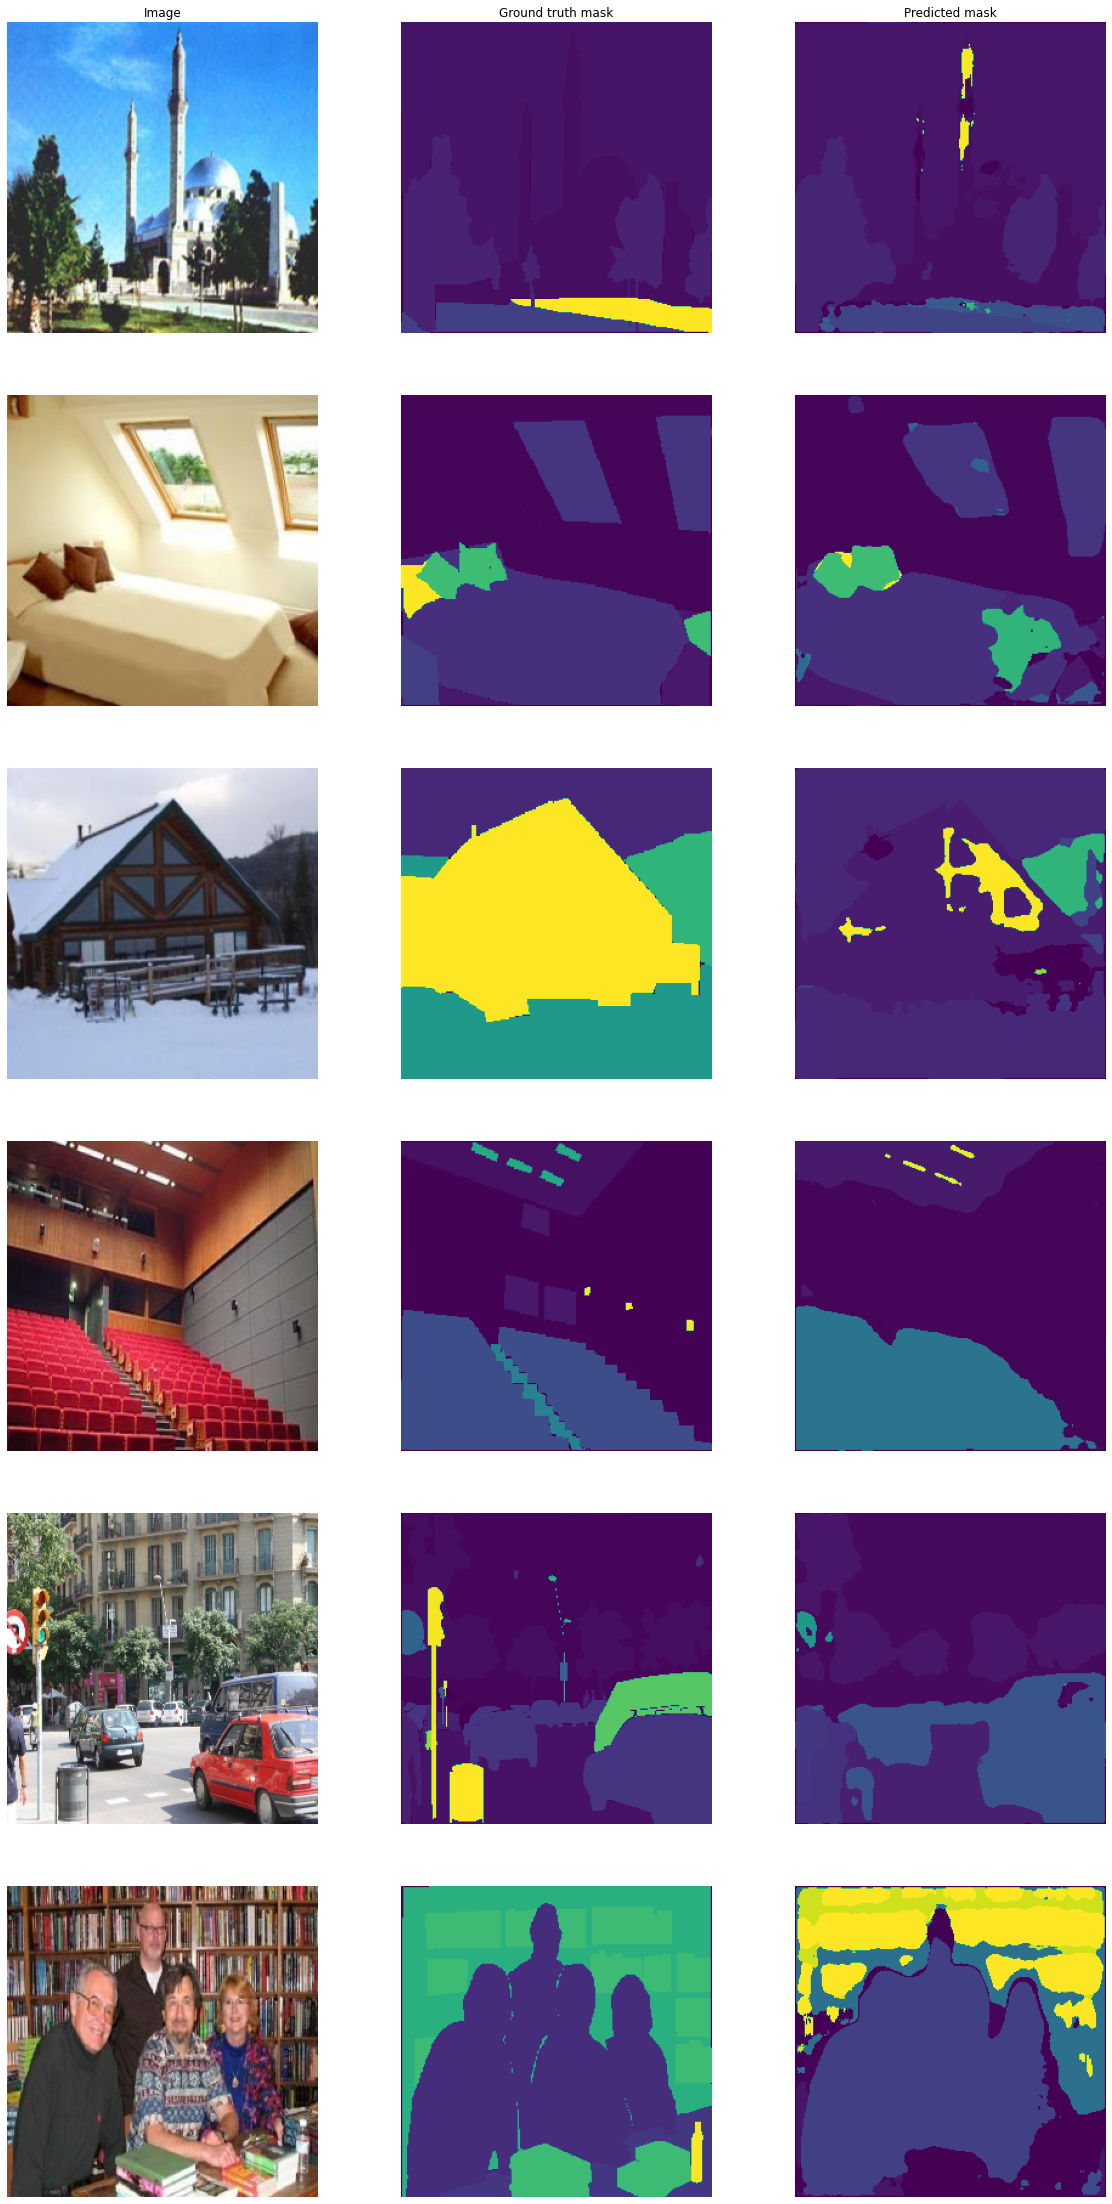

In [14]:
plot_predicted_mask(val_loader, unet, num_images=6, height=40, device=device)